# <b> Comparing retrievals for the measured & TROPOMI-derived OCI Spectra <b>

## <b> Bulk comparison <b>

In [1]:
import numpy as np
import pandas as pd
import os
import xarray as xr
import matplotlib.pyplot as plt


In [34]:
# test
root_dir = "/home/zhe2/data/MyProjects/PACE_redSIF_PACE/TROPOMI_OCI_colocation_data/runs/july2025_d01-31/"
test_name = "sif_retrieval_nPC_15_npoly_10/"

# sims
path_sim = os.path.join(root_dir, test_name, "matchup_sif_sim_noisy.nc")
ds_sim = xr.open_dataset(path_sim)

# meas
path_meas = os.path.join(root_dir, test_name, "matchup_sif_meas.nc")
ds_meas = xr.open_dataset(path_meas)


In [35]:
# statistics on # of converged retrievals
sim_converged = ds_sim["converged"].values
meas_converged = ds_meas["converged"].values
print("Number of converged retrievals:")
print(f"Real OCI spectra: {np.sum(meas_converged)}")
print(f"Simulated spectra: {np.sum(sim_converged)}")


Number of converged retrievals:
Real OCI spectra: 77
Simulated spectra: 409


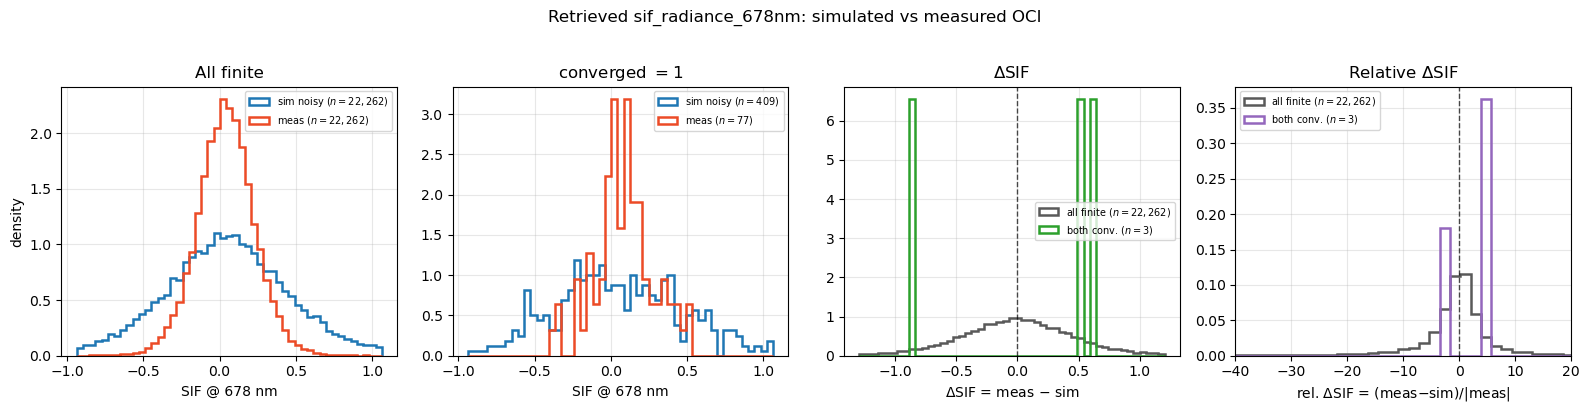

all finite   median sim=0.04637  meas=0.0402
converged    median sim=0.00922  meas=0.08766
ΔSIF median  all=-0.006722  both-conv=0.5213
rel ΔSIF median all=-0.05106  both-conv=4.291


In [36]:
# SIF distributions: all finite | converged | ΔSIF | relative ΔSIF
sif_sim = np.asarray(ds_sim["sif_radiance_678nm"].values, dtype=float)
sif_meas = np.asarray(ds_meas["sif_radiance_678nm"].values, dtype=float)
conv_sim = np.asarray(ds_sim["converged"].values).astype(bool)
conv_meas = np.asarray(ds_meas["converged"].values).astype(bool)

sim_all = sif_sim[np.isfinite(sif_sim)]
meas_all = sif_meas[np.isfinite(sif_meas)]
sim_ok = sif_sim[conv_sim & np.isfinite(sif_sim)]
meas_ok = sif_meas[conv_meas & np.isfinite(sif_meas)]

# paired differences (same match index)
m_all = np.isfinite(sif_sim) & np.isfinite(sif_meas)
m_ok = m_all & conv_sim & conv_meas
diff_all = sif_meas[m_all] - sif_sim[m_all]
diff_ok = sif_meas[m_ok] - sif_sim[m_ok]

# relative ΔSIF = (meas − sim) / |meas|
eps = 1e-6
rel_all = diff_all / np.maximum(np.abs(sif_meas[m_all]), eps)
rel_ok = diff_ok / np.maximum(np.abs(sif_meas[m_ok]), eps)

pool = np.concatenate([a for a in (sim_all, meas_all) if a.size])
lo, hi = np.nanpercentile(pool, [1, 99])
bins = np.linspace(lo, hi, 50)

diff_pool = np.concatenate([a for a in (diff_all, diff_ok) if a.size])
dlo, dhi = np.nanpercentile(diff_pool, [1, 99])
dbins = np.linspace(dlo, dhi, 50)

rel_pool = np.concatenate([a for a in (rel_all, rel_ok) if a.size])
rlo, rhi = np.nanpercentile(rel_pool, [1, 99])
rbins = np.linspace(rlo, rhi, 80)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.0))

for ax, sim_v, meas_v, title in [
    (axes[0], sim_all, meas_all, "All finite"),
    (axes[1], sim_ok, meas_ok, r"converged $= 1$"),
]:
    ax.hist(sim_v, bins=bins, histtype="step", lw=1.8, density=True,
            color="#1f77b4", label=fr"sim noisy ($n={sim_v.size:,}$)")
    ax.hist(meas_v, bins=bins, histtype="step", lw=1.8, density=True,
            color="#EC4B26", label=fr"meas ($n={meas_v.size:,}$)")
    ax.set_xlabel(r"SIF @ 678 nm")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

axes[0].set_ylabel("density")

ax = axes[2]
ax.hist(diff_all, bins=dbins, histtype="step", lw=1.8, density=True,
        color="0.35", label=fr"all finite ($n={diff_all.size:,}$)")
ax.hist(diff_ok, bins=dbins, histtype="step", lw=1.8, density=True,
        color="#2ca02c", label=fr"both conv. ($n={diff_ok.size:,}$)")
ax.axvline(0.0, color="k", ls="--", lw=1.0, alpha=0.7)
ax.set_xlabel(r"$\Delta$SIF = meas − sim")
ax.set_title(r"$\Delta$SIF")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7)

ax = axes[3]
ax.hist(rel_all, bins=rbins, histtype="step", lw=1.8, density=True,
        color="0.35", label=fr"all finite ($n={rel_all.size:,}$)")
ax.hist(rel_ok, bins=rbins, histtype="step", lw=1.8, density=True,
        color="#9467bd", label=fr"both conv. ($n={rel_ok.size:,}$)")
ax.axvline(0.0, color="k", ls="--", lw=1.0, alpha=0.7)
ax.set_xlabel(r"rel. $\Delta$SIF = (meas−sim)$/|$meas$|$")
ax.set_xlim(-40, 20)
ax.set_title(r"Relative $\Delta$SIF")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7)

fig.suptitle("Retrieved sif_radiance_678nm: simulated vs measured OCI", y=1.02)
plt.tight_layout()
plt.show()

print(f"all finite   median sim={np.nanmedian(sim_all):.4g}  meas={np.nanmedian(meas_all):.4g}")
print(f"converged    median sim={np.nanmedian(sim_ok):.4g}  meas={np.nanmedian(meas_ok):.4g}")
print(f"ΔSIF median  all={np.nanmedian(diff_all):.4g}  both-conv={np.nanmedian(diff_ok):.4g}")
print(f"rel ΔSIF median all={np.nanmedian(rel_all):.4g}  both-conv={np.nanmedian(rel_ok):.4g}")


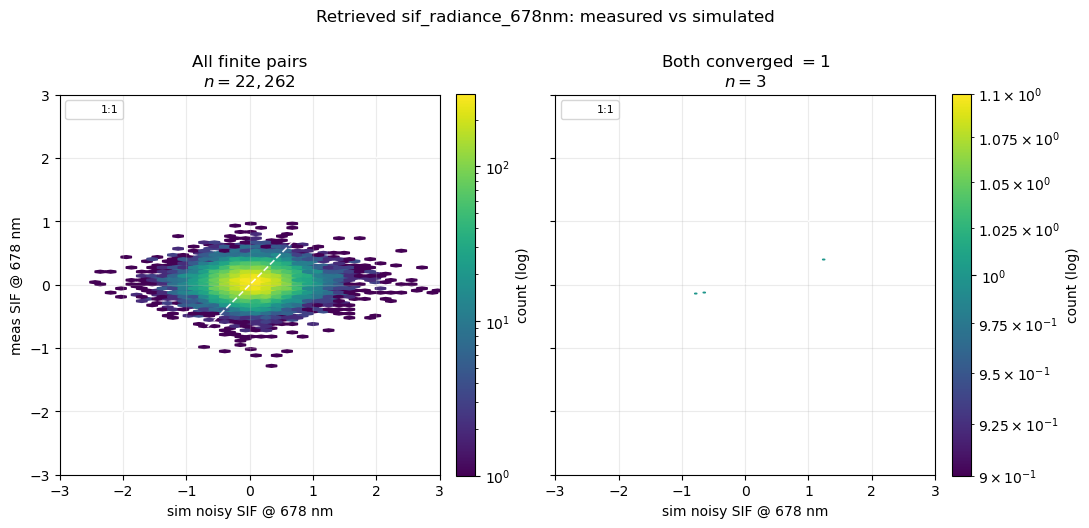

converged pairs: n=3  corr=0.999  mean(meas−sim)=0.1075


In [37]:
# Scatter-density: measured vs simulated sif_radiance_678nm (same match index)
x_all, y_all = sif_sim, sif_meas
m_all = np.isfinite(x_all) & np.isfinite(y_all)
m_ok = m_all & conv_sim & conv_meas

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

for ax, mask, title in [
    (axes[0], m_all, "All finite pairs"),
    (axes[1], m_ok, r"Both converged $= 1$"),
]:
    x, y = x_all[mask], y_all[mask]
    hb = ax.hexbin(x, y, gridsize=60, mincnt=1, bins="log", cmap="viridis")
    # 1:1 reference over data range
    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))
    ax.plot([lo, hi], [lo, hi], "w--", lw=1.2, alpha=0.9, label="1:1")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"sim noisy SIF @ 678 nm")
    ax.set_title(f"{title}\n$n={x.size:,}$")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", fontsize=8)
    cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("count (log)")

axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)
axes[0].set_ylabel(r"meas SIF @ 678 nm")
fig.suptitle("Retrieved sif_radiance_678nm: measured vs simulated", y=1.02)
plt.tight_layout()
plt.show()

# quick stats on converged pairs
if m_ok.any():
    r = np.corrcoef(x_all[m_ok], y_all[m_ok])[0, 1]
    bias = np.nanmean(y_all[m_ok] - x_all[m_ok])
    print(f"converged pairs: n={m_ok.sum():,}  corr={r:.3f}  mean(meas−sim)={bias:.4g}")


both converged with finite spectra/|ΔVZA|/SIF: 3 / 22,262
bin 1/4: |ΔVZA| ∈ [5.19, 8.14]°  n=1  show=1
bin 2/4: |ΔVZA| ∈ [8.14, 11.08]°  n=0  show=0
bin 3/4: |ΔVZA| ∈ [11.08, 23.52]°  n=1  show=1
bin 4/4: |ΔVZA| ∈ [23.52, 35.95]°  n=1  show=1


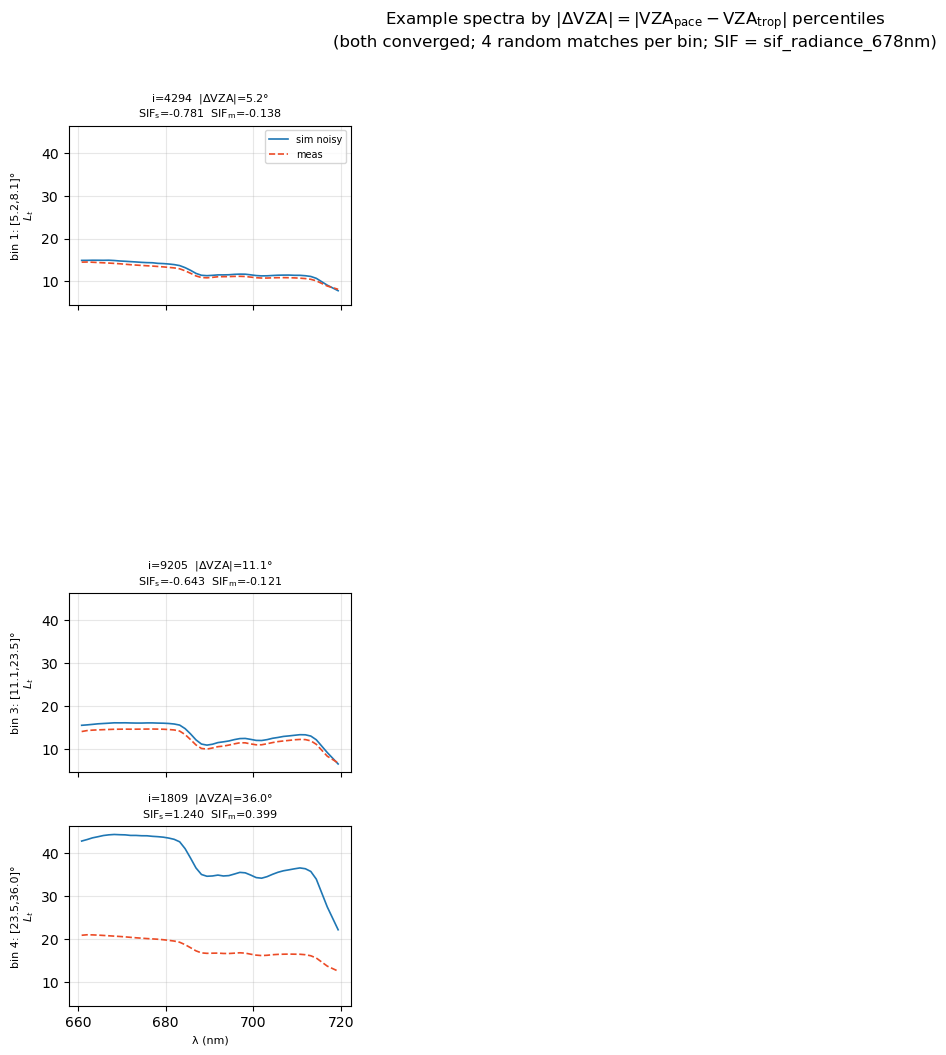

In [38]:
# Example spectra: 4 abs(ΔVZA) percentile bins × 4 random both-converged matches
# |ΔVZA| = |vza_pace − vza_trop|; spectra from matchup.nc; SIF from retrieval NCs

RNG = np.random.default_rng(0)
N_BINS, N_PER_BIN = 4, 4

path_mu = os.path.join(root_dir, "products", "matchup.nc")
ds_mu = xr.open_dataset(path_mu)
band = np.asarray(ds_mu["band"].values, dtype=float)
lt_sim = np.asarray(ds_mu["lt_oci_sim_noisy"].values, dtype=float)   # (match, band)
lt_meas = np.asarray(ds_mu["lt_oci_meas"].values, dtype=float)
vza_p = np.asarray(ds_sim["vza_pace"].values, dtype=float)
vza_t = np.asarray(ds_sim["vza_trop"].values, dtype=float)
abs_dvza = np.abs(vza_p - vza_t)

both = (
    conv_sim & conv_meas
    & np.isfinite(abs_dvza)
    & np.isfinite(lt_sim).all(axis=1)
    & np.isfinite(lt_meas).all(axis=1)
    & np.isfinite(sif_sim)
    & np.isfinite(sif_meas)
)
idx = np.flatnonzero(both)
print(f"both converged with finite spectra/|ΔVZA|/SIF: {idx.size:,} / {abs_dvza.size:,}")

qs = np.linspace(0, 100, N_BINS + 1)
edges = np.percentile(abs_dvza[idx], qs)

fig, axes = plt.subplots(
    N_BINS, N_PER_BIN, figsize=(3.2 * N_PER_BIN, 2.6 * N_BINS), sharex=True, sharey=True
)

for b in range(N_BINS):
    lo_e, hi_e = edges[b], edges[b + 1]
    if b < N_BINS - 1:
        in_bin = idx[(abs_dvza[idx] >= lo_e) & (abs_dvza[idx] < hi_e)]
    else:
        in_bin = idx[(abs_dvza[idx] >= lo_e) & (abs_dvza[idx] <= hi_e)]
    n_pick = min(N_PER_BIN, in_bin.size)
    pick = RNG.choice(in_bin, size=n_pick, replace=False) if n_pick else np.array([], dtype=int)
    print(
        f"bin {b+1}/{N_BINS}: |ΔVZA| ∈ [{lo_e:.2f}, {hi_e:.2f}]°  "
        f"n={in_bin.size:,}  show={n_pick}"
    )

    for j in range(N_PER_BIN):
        ax = axes[b, j]
        if j >= n_pick:
            ax.set_visible(False)
            continue
        i = int(pick[j])
        ax.plot(band, lt_sim[i], color="#1f77b4", lw=1.2, label="sim noisy")
        ax.plot(band, lt_meas[i], color="#EC4B26", lw=1.2, ls="--", label="meas")
        ax.set_title(
            fr"i={i}  $|\Delta$VZA$|$={abs_dvza[i]:.1f}°"
            f"\nSIF$_\\mathrm{{s}}$={sif_sim[i]:.3f}  SIF$_\\mathrm{{m}}$={sif_meas[i]:.3f}",
            fontsize=8,
        )
        ax.grid(True, alpha=0.3)
        if b == N_BINS - 1:
            ax.set_xlabel("λ (nm)", fontsize=8)
        if j == 0:
            ax.set_ylabel(
                fr"bin {b+1}: [{lo_e:.1f},{hi_e:.1f}]°" + "\n$L_t$",
                fontsize=8,
            )
        if b == 0 and j == 0:
            ax.legend(fontsize=7, loc="best")

fig.suptitle(
    r"Example spectra by $|\Delta$VZA$|=|$VZA$_\mathrm{pace}-$VZA$_\mathrm{trop}|$ percentiles"
    "\n(both converged; 4 random matches per bin; SIF = sif_radiance_678nm)",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.show()
ds_mu.close()


both converged with finite spectra/|Δ〈Lt_r〉|/SIF: 3 / 22,262
bin 1/4: |Δ〈Lt_r〉| ∈ [1.123, 7.799]  n=1  show=1
bin 2/4: |Δ〈Lt_r〉| ∈ [7.799, 14.47]  n=0  show=0
bin 3/4: |Δ〈Lt_r〉| ∈ [14.47, 17.74]  n=1  show=1
bin 4/4: |Δ〈Lt_r〉| ∈ [17.74, 21.01]  n=1  show=1


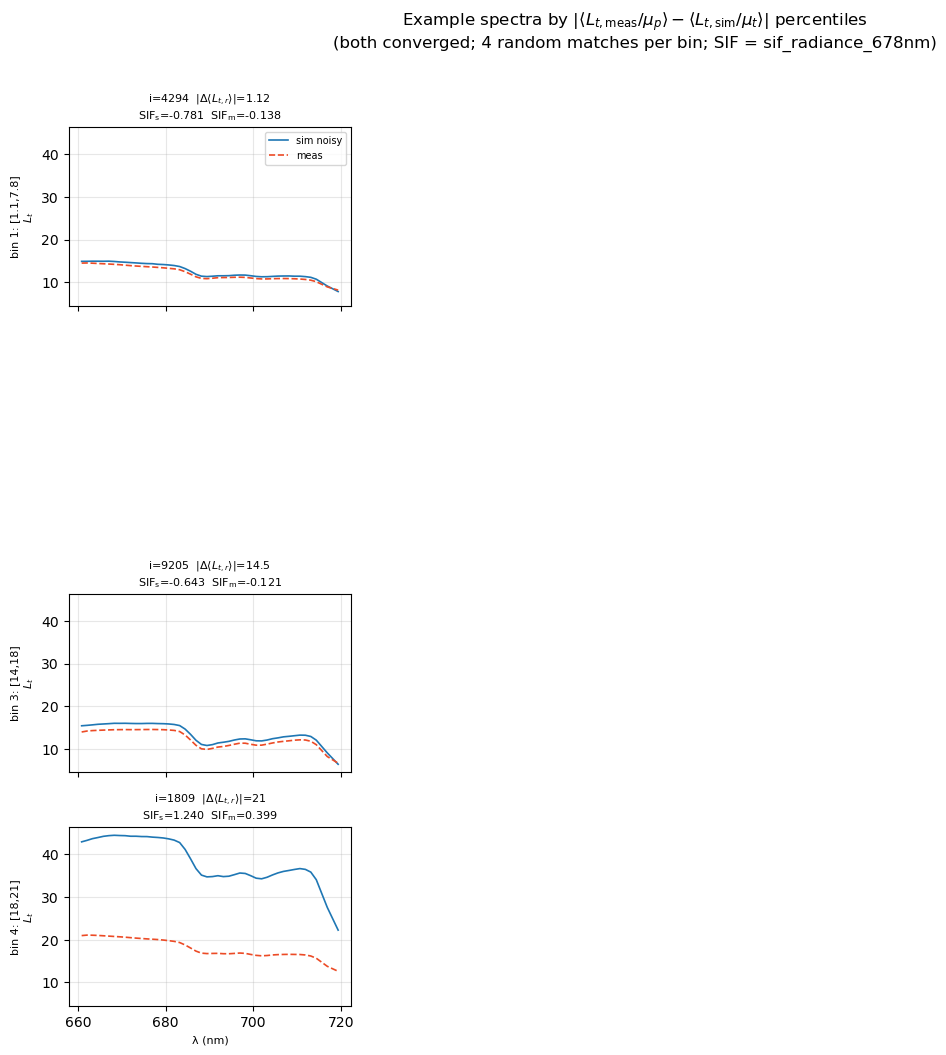

In [39]:
# Example spectra: 4 abs(Δ〈Lt_rescaled〉) percentile bins × 4 random both-converged matches
# Lt_rescaled = Lt / cos(SZA); sim uses sza_trop, meas uses sza_pace
# metric = |mean(Lt_meas/μ_p) − mean(Lt_sim/μ_t)|

RNG = np.random.default_rng(1)
N_BINS, N_PER_BIN = 4, 4

path_mu = os.path.join(root_dir, "products", "matchup.nc")
ds_mu = xr.open_dataset(path_mu)
band = np.asarray(ds_mu["band"].values, dtype=float)
lt_sim = np.asarray(ds_mu["lt_oci_sim_noisy"].values, dtype=float)   # (match, band)
lt_meas = np.asarray(ds_mu["lt_oci_meas"].values, dtype=float)
sza_p = np.asarray(ds_sim["sza_pace"].values, dtype=float)
sza_t = np.asarray(ds_sim["sza_trop"].values, dtype=float)
mu_p = np.maximum(np.cos(np.deg2rad(sza_p)), 1e-6)
mu_t = np.maximum(np.cos(np.deg2rad(sza_t)), 1e-6)

lt_sim_r = lt_sim / mu_t[:, None]
lt_meas_r = lt_meas / mu_p[:, None]
abs_dmean = np.abs(np.nanmean(lt_meas_r, axis=1) - np.nanmean(lt_sim_r, axis=1))

both = (
    conv_sim & conv_meas
    & np.isfinite(abs_dmean)
    & np.isfinite(lt_sim).all(axis=1)
    & np.isfinite(lt_meas).all(axis=1)
    & np.isfinite(sif_sim)
    & np.isfinite(sif_meas)
)
idx = np.flatnonzero(both)
print(f"both converged with finite spectra/|Δ〈Lt_r〉|/SIF: {idx.size:,} / {abs_dmean.size:,}")

qs = np.linspace(0, 100, N_BINS + 1)
edges = np.percentile(abs_dmean[idx], qs)

fig, axes = plt.subplots(
    N_BINS, N_PER_BIN, figsize=(3.2 * N_PER_BIN, 2.6 * N_BINS), sharex=True, sharey=True
)

for b in range(N_BINS):
    lo_e, hi_e = edges[b], edges[b + 1]
    if b < N_BINS - 1:
        in_bin = idx[(abs_dmean[idx] >= lo_e) & (abs_dmean[idx] < hi_e)]
    else:
        in_bin = idx[(abs_dmean[idx] >= lo_e) & (abs_dmean[idx] <= hi_e)]
    n_pick = min(N_PER_BIN, in_bin.size)
    pick = RNG.choice(in_bin, size=n_pick, replace=False) if n_pick else np.array([], dtype=int)
    print(
        f"bin {b+1}/{N_BINS}: |Δ〈Lt_r〉| ∈ [{lo_e:.4g}, {hi_e:.4g}]  "
        f"n={in_bin.size:,}  show={n_pick}"
    )

    for j in range(N_PER_BIN):
        ax = axes[b, j]
        if j >= n_pick:
            ax.set_visible(False)
            continue
        i = int(pick[j])
        ax.plot(band, lt_sim[i], color="#1f77b4", lw=1.2, label="sim noisy")
        ax.plot(band, lt_meas[i], color="#EC4B26", lw=1.2, ls="--", label="meas")
        ax.set_title(
            fr"i={i}  $|\Delta\langle L_{{t,r}}\rangle|$={abs_dmean[i]:.3g}"
            f"\nSIF$_\\mathrm{{s}}$={sif_sim[i]:.3f}  SIF$_\\mathrm{{m}}$={sif_meas[i]:.3f}",
            fontsize=8,
        )
        ax.grid(True, alpha=0.3)
        if b == N_BINS - 1:
            ax.set_xlabel("λ (nm)", fontsize=8)
        if j == 0:
            ax.set_ylabel(
                fr"bin {b+1}: [{lo_e:.2g},{hi_e:.2g}]" + "\n$L_t$",
                fontsize=8,
            )
        if b == 0 and j == 0:
            ax.legend(fontsize=7, loc="best")

fig.suptitle(
    r"Example spectra by $|\langle L_{t,\mathrm{meas}}/\mu_p\rangle-\langle L_{t,\mathrm{sim}}/\mu_t\rangle|$ percentiles"
    "\n(both converged; 4 random matches per bin; SIF = sif_radiance_678nm)",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.show()
ds_mu.close()


## <b> Sensitivity to viewing geometry? <b>

## <b>Sensitivity to state vector? </b>

In [40]:
# State-vector sensitivity: retrieval setups to compare
root_dir = "/home/zhe2/data/MyProjects/PACE_redSIF_PACE/TROPOMI_OCI_colocation_data/runs/july2025_d01-31/"

test_names = [
    "sif_retrieval_nPC_15_npoly_5/",
    "sif_retrieval_nPC_15_npoly_10/",
    "sif_retrieval_nPC_10_npoly_5/",
    "sif_retrieval_nPC_20_npoly_5/",
]

label_names = [
    "nPC=15, npoly=5",
    "nPC=15, npoly=10",
    "nPC=10, npoly=5",
    "nPC=20, npoly=5",
]


In [41]:
# Load sif_radiance_678nm + convergence for each (nPC, npoly) run
runs = []
for name, label in zip(test_names, label_names):
    p_sim = os.path.join(root_dir, name, "matchup_sif_sim_noisy.nc")
    p_meas = os.path.join(root_dir, name, "matchup_sif_meas.nc")
    if not (os.path.isfile(p_sim) and os.path.isfile(p_meas)):
        print(f"SKIP missing: {label}\n  {p_sim}\n  {p_meas}")
        continue
    ds_s = xr.open_dataset(p_sim)
    ds_m = xr.open_dataset(p_meas)
    sif_s = np.asarray(ds_s["sif_radiance_678nm"].values, dtype=float)
    sif_m = np.asarray(ds_m["sif_radiance_678nm"].values, dtype=float)
    conv_s = np.asarray(ds_s["converged"].values).astype(bool)
    conv_m = np.asarray(ds_m["converged"].values).astype(bool)
    ds_s.close()
    ds_m.close()
    runs.append(
        dict(
            name=name,
            label=label,
            sif_sim=sif_s,
            sif_meas=sif_m,
            conv_sim=conv_s,
            conv_meas=conv_m,
        )
    )
    print(
        f"{label}: n={sif_m.size:,}  "
        f"meas_conv={conv_m.sum():,}  sim_conv={conv_s.sum():,}  "
        f"both={ (conv_m & conv_s).sum():,}"
    )

assert runs, "no retrieval products found"


nPC=15, npoly=5: n=22,262  meas_conv=7,031  sim_conv=5,709  both=2,038
nPC=15, npoly=10: n=22,262  meas_conv=77  sim_conv=409  both=3
nPC=10, npoly=5: n=22,262  meas_conv=15,941  sim_conv=15,102  both=11,482
nPC=20, npoly=5: n=22,262  meas_conv=632  sim_conv=633  both=26


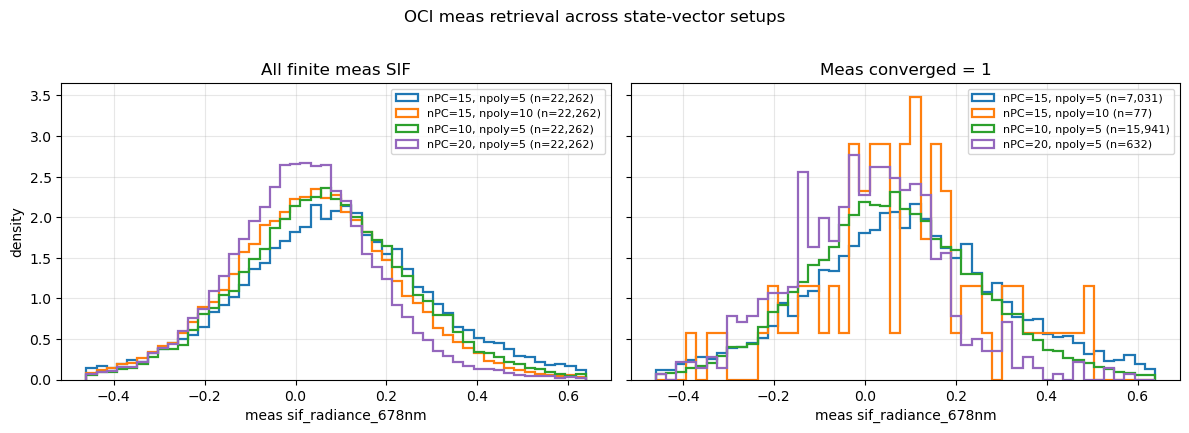

In [42]:
# Meas SIF histograms across configs (all finite | meas converged)
colors = plt.cm.tab10(np.linspace(0, 0.4, len(runs)))

pool = np.concatenate(
    [
        r["sif_meas"][np.isfinite(r["sif_meas"])]
        for r in runs
        if np.isfinite(r["sif_meas"]).any()
    ]
)
lo, hi = np.nanpercentile(pool, [1, 99])
bins = np.linspace(lo, hi, 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, use_conv, title in [
    (axes[0], False, "All finite meas SIF"),
    (axes[1], True, "Meas converged = 1"),
]:
    for r, c in zip(runs, colors):
        sif_m = r["sif_meas"]
        mask = np.isfinite(sif_m)
        if use_conv:
            mask &= r["conv_meas"]
        ax.hist(
            sif_m[mask],
            bins=bins,
            histtype="step",
            density=True,
            lw=1.6,
            color=c,
            label=f"{r['label']} (n={mask.sum():,})",
        )
    ax.set_xlabel(r"meas sif_radiance_678nm")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")

axes[0].set_ylabel("density")
fig.suptitle("OCI meas retrieval across state-vector setups", y=1.02)
plt.tight_layout()
plt.show()


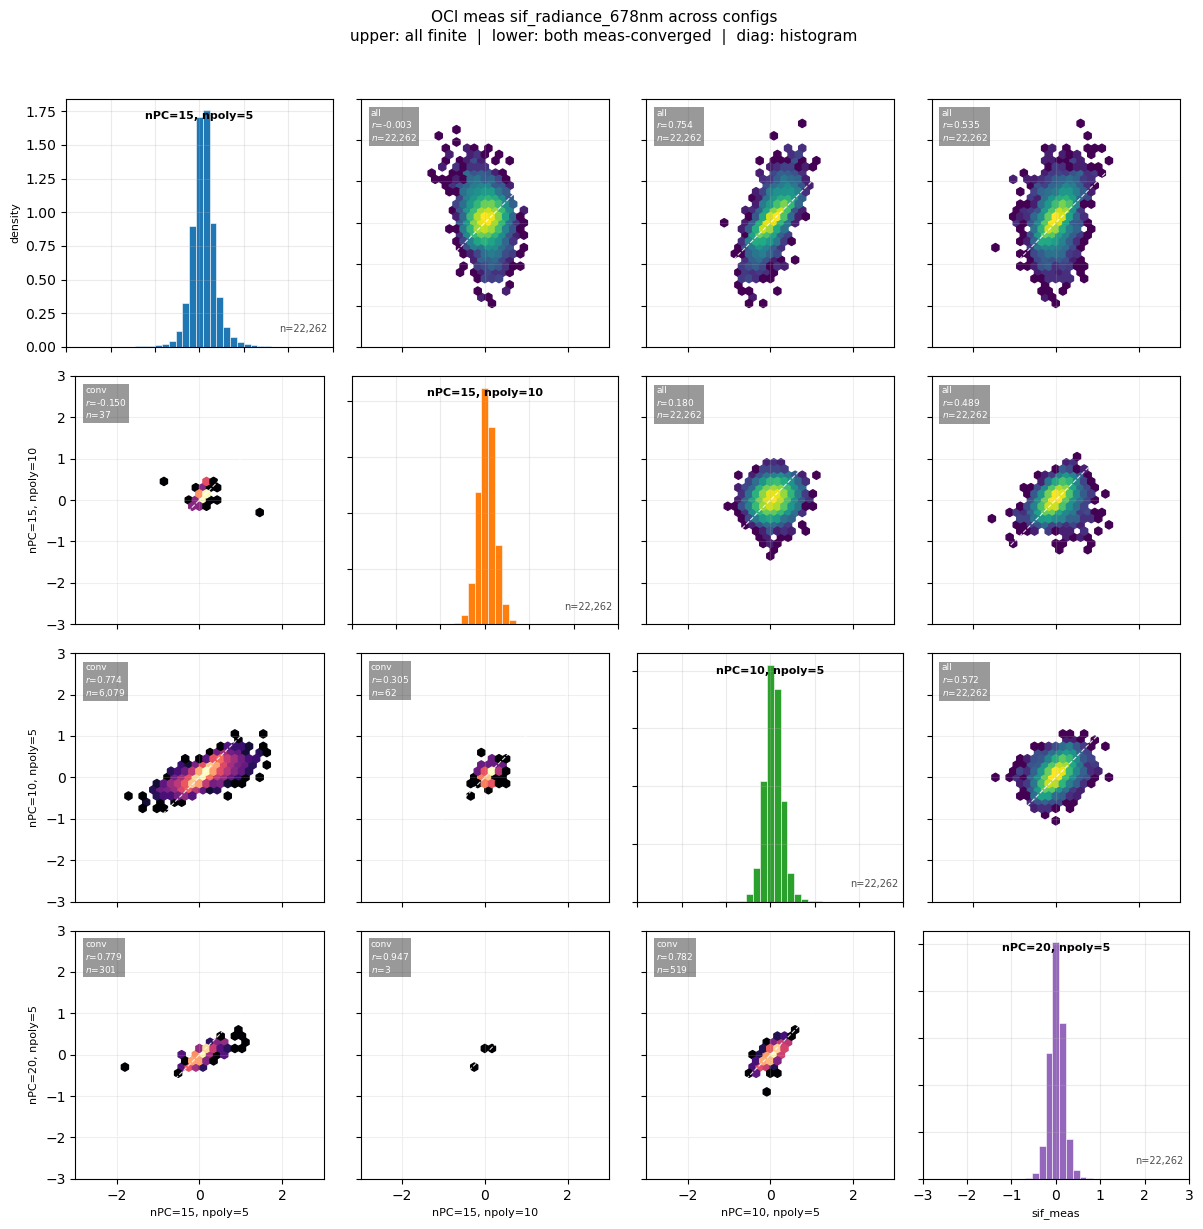

In [43]:
# Pairwise sif_meas: upper=all finite hexbin, lower=both meas-converged hexbin, diag=hist
n = len(runs)
labels = [r["label"] for r in runs]
meas = [r["sif_meas"] for r in runs]
conv = [r["conv_meas"] for r in runs]

lo, hi = -3.0, 3.0
bins = np.linspace(lo, hi, 40)
colors = plt.cm.tab10(np.linspace(0, 0.4, n))

fig, axes = plt.subplots(n, n, figsize=(3.0 * n, 3.0 * n))
if n == 1:
    axes = np.asarray([[axes]])

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        # Diagonal: histogram of this config's meas SIF
        if i == j:
            y = meas[i]
            m = np.isfinite(y)
            ax.hist(
                y[m],
                bins=bins,
                color=colors[i],
                edgecolor="white",
                linewidth=0.4,
                density=True,
            )
            ax.set_xlim(lo, hi)
            ax.text(
                0.50,
                0.95,
                labels[i],
                transform=ax.transAxes,
                ha="center",
                va="top",
                fontsize=8,
                fontweight="bold",
            )
            ax.text(
                0.98,
                0.05,
                f"n={m.sum():,}",
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=7,
                color="0.3",
            )
            ax.grid(True, alpha=0.25)
            if i == n - 1:
                ax.set_xlabel(r"sif_meas", fontsize=8)
            else:
                ax.tick_params(labelbottom=False)
            if j == 0:
                ax.set_ylabel("density", fontsize=8)
            else:
                ax.tick_params(labelleft=False)
            continue

        # Off-diagonal hexbin: column j = x, row i = y
        x, y = meas[j], meas[i]
        if i < j:
            # upper triangle: all finite
            m = np.isfinite(x) & np.isfinite(y)
            tag = "all"
            cmap = "viridis"
        else:
            # lower triangle: both configs meas-converged
            m = np.isfinite(x) & np.isfinite(y) & conv[j] & conv[i]
            tag = "conv"
            cmap = "magma"

        xx, yy = x[m], y[m]
        if xx.size:
            ax.hexbin(xx, yy, gridsize=35, mincnt=1, bins="log", cmap=cmap, extent=[lo, hi, lo, hi])
            r = float(np.corrcoef(xx, yy)[0, 1]) if xx.size > 1 else np.nan
            ax.text(
                0.04,
                0.96,
                f"{tag}\n$r$={r:.3f}\n$n$={xx.size:,}",
                transform=ax.transAxes,
                va="top",
                ha="left",
                fontsize=6.5,
                color="w",
                bbox=dict(facecolor="k", alpha=0.4, edgecolor="none", pad=1.5),
            )
        ax.plot([lo, hi], [lo, hi], color="w", ls="--", lw=0.8, alpha=0.85)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.2)

        if i == n - 1:
            ax.set_xlabel(labels[j], fontsize=8)
        else:
            ax.tick_params(labelbottom=False)
        if j == 0:
            ax.set_ylabel(labels[i], fontsize=8)
        else:
            ax.tick_params(labelleft=False)

fig.suptitle(
    "OCI meas sif_radiance_678nm across configs\n"
    r"upper: all finite  |  lower: both meas-converged  |  diag: histogram",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()


,setup,mask,n,meas_mean,sim_mean,dSIF_mean,dSIF_std,dSIF_med,rel_med,rmse,r
0,"nPC=15, npoly=5",all_finite,22262,0.0905,0.2218,-0.1313,0.4585,-0.0986,-0.6968,0.4769,0.0276
1,"nPC=15, npoly=5",both_conv,2038,0.1080,0.2877,-0.1796,0.5331,-0.1438,-0.8377,0.5626,0.0431
2,"nPC=15, npoly=10",all_finite,22262,0.0395,0.0514,-0.0118,0.4974,-0.0067,-0.0511,0.4976,0.0072
3,"nPC=15, npoly=10",both_conv,3,0.0465,-0.0610,0.1075,0.6726,0.5213,4.2914,0.6811,0.9994
4,"nPC=10, npoly=5",all_finite,22262,0.0663,0.2653,-0.1990,0.4084,-0.1544,-1.2925,0.4543,0.0211
5,"nPC=10, npoly=5",both_conv,11482,0.0630,0.3045,-0.2414,0.4007,-0.1944,-1.5781,0.4678,0.0324
6,"nPC=20, npoly=5",all_finite,22262,0.0153,0.0846,-0.0693,0.4344,-0.0597,-0.5440,0.4399,0.0186
7,"nPC=20, npoly=5",both_conv,26,0.0107,-0.1788,0.1895,0.7880,0.0201,0.2952,0.8104,0.3206


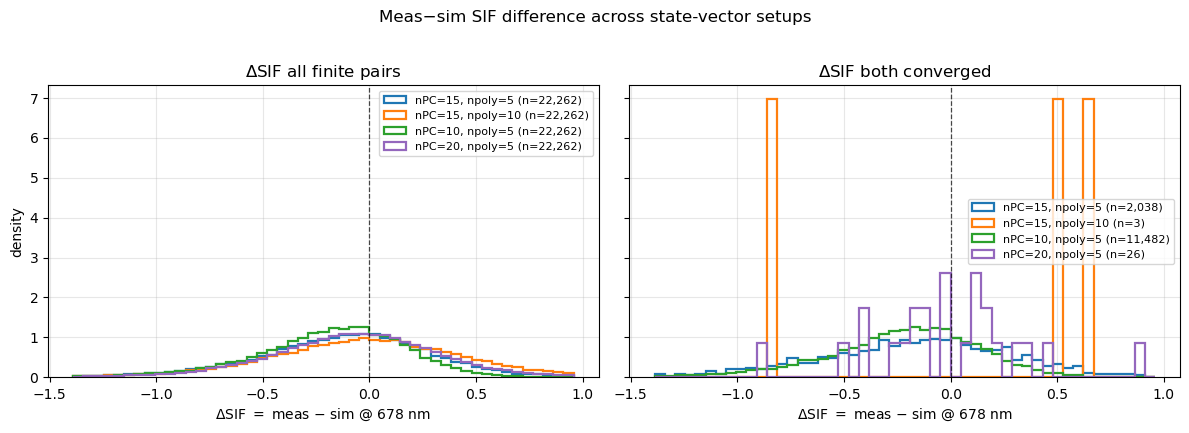

In [44]:
# ΔSIF = meas − sim distributions + paired summary stats (all finite | both converged)
eps = 1e-6
rows = []
diff_pools = []

for r in runs:
    x, y = r["sif_sim"], r["sif_meas"]
    m_all = np.isfinite(x) & np.isfinite(y)
    m_ok = m_all & r["conv_sim"] & r["conv_meas"]
    for mask, tag in [(m_all, "all_finite"), (m_ok, "both_conv")]:
        d = y[mask] - x[mask]
        rel = d / np.maximum(np.abs(y[mask]), eps)
        rows.append(
            dict(
                setup=r["label"],
                mask=tag,
                n=int(mask.sum()),
                meas_mean=float(np.nanmean(y[mask])) if mask.any() else np.nan,
                sim_mean=float(np.nanmean(x[mask])) if mask.any() else np.nan,
                dSIF_mean=float(np.nanmean(d)) if d.size else np.nan,
                dSIF_std=float(np.nanstd(d)) if d.size else np.nan,
                dSIF_med=float(np.nanmedian(d)) if d.size else np.nan,
                rel_med=float(np.nanmedian(rel)) if rel.size else np.nan,
                rmse=float(np.sqrt(np.nanmean(d**2))) if d.size else np.nan,
                r=float(np.corrcoef(x[mask], y[mask])[0, 1]) if mask.sum() > 1 else np.nan,
            )
        )
        if d.size:
            diff_pools.append(d)

df = pd.DataFrame(rows)
display(df.round(4))

pool = np.concatenate(diff_pools) if diff_pools else np.array([0.0])
dlo, dhi = np.nanpercentile(pool, [1, 99])
dbins = np.linspace(dlo, dhi, 50)
colors = plt.cm.tab10(np.linspace(0, 0.4, len(runs)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, tag, title in [
    (axes[0], "all_finite", r"$\Delta$SIF all finite pairs"),
    (axes[1], "both_conv", r"$\Delta$SIF both converged"),
]:
    for r, c in zip(runs, colors):
        x, y = r["sif_sim"], r["sif_meas"]
        m = np.isfinite(x) & np.isfinite(y)
        if tag == "both_conv":
            m &= r["conv_sim"] & r["conv_meas"]
        d = y[m] - x[m]
        ax.hist(
            d,
            bins=dbins,
            histtype="step",
            density=True,
            lw=1.6,
            color=c,
            label=f"{r['label']} (n={m.sum():,})",
        )
    ax.axvline(0, color="k", ls="--", lw=0.9, alpha=0.7)
    ax.set_xlabel(r"$\Delta$SIF $=$ meas $-$ sim @ 678 nm")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")

axes[0].set_ylabel("density")
fig.suptitle("Meas−sim SIF difference across state-vector setups", y=1.02)
plt.tight_layout()
plt.show()
